### Code funzionante

LSB --- MSB in OpenFHE

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

In [2]:
bits = 64

In [3]:
class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [15]:
x = random.getrandbits(14)
x

15065

In [7]:
p1 = np.floor(x / 128)
p1

73.0

In [10]:
# Questo dovrebbe essere facile con sin
p2 = x % 128
p2

3

In [16]:
x / 128

117.6953125

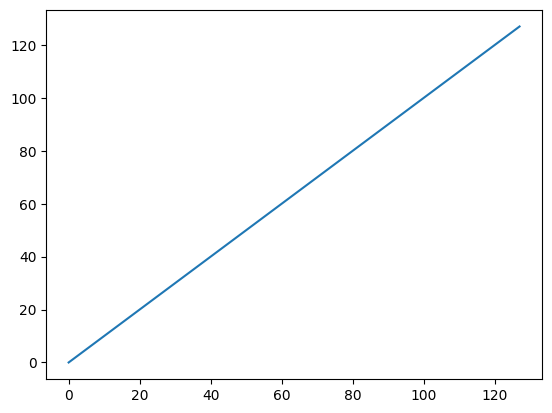

In [13]:
x = np.arange(0, 16384/128, 1)

y = np.floor(x)

plt.plot(x, y)

In [139]:
def double_angle(sin_x, cos_x):
    return 2 * sin_x * cos_x, 1 - 2 * sin_x**2

def sin_mod128(n):
    # argomento iniziale piccolo: 2π*n / (128 * 2^4)
    theta = 2 * np.pi * n / (128 * 16)

    # approssimazione sin(x) ≈ x, cos(x) ≈ 1 - x²/2
    s = theta
    c = 1 - theta**2 / 2

    # 4 step di double angle
    for _ in range(4):
        s, c = double_angle(s, c)

    return s  # ≈ sin(2π*n/128)

In [147]:
c = Chebyshev(0, 1024, 581, np.sin)

1.6897594434794883e-12


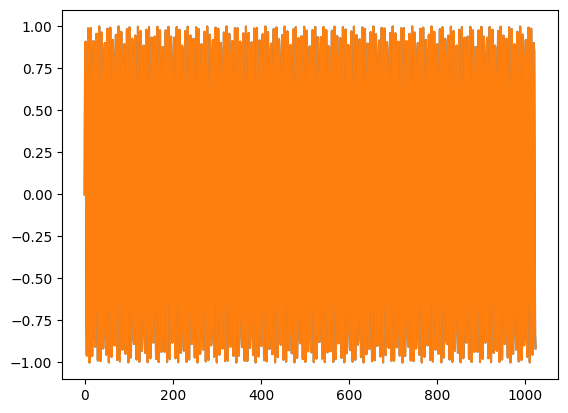

In [148]:
x = np.arange(0, 1024, 1)

y = np.sin(x)

plt.plot(x, y)

y_real = np.vectorize(c.eval)(x)

plt.plot(x, y_real)

print(max(y - y_real))

In [151]:
def sin_mod128(x):
    global c
    theta = 2 * np.pi * x / (128 * 16)

    t1 = c.eval(theta)
    t2 = 1 - theta**2 / 2

    # 4 step di double angle
    for _ in range(4):
        t1, t2 = double_angle(t1, t2)

    return t1  # ≈ sin(2π*n/128)

In [152]:
sin_mod128(4023)

3887011859.261911

In [35]:
c.eval(3412 / 128)

26.034302066236286

In [36]:
np.floor(3412 / 128)

26.0

---

In [75]:
def sgn(x):
    return 1/(1 + np.exp(-7 * x))

def clean(x):
    return -2*x**3+3*x**2

/var/folders/f4/cjlhwcw50v97ltsgj1fxyssm0000gn/T/ipykernel_7116/3401730692.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-7 * x))


0.016832680149019653


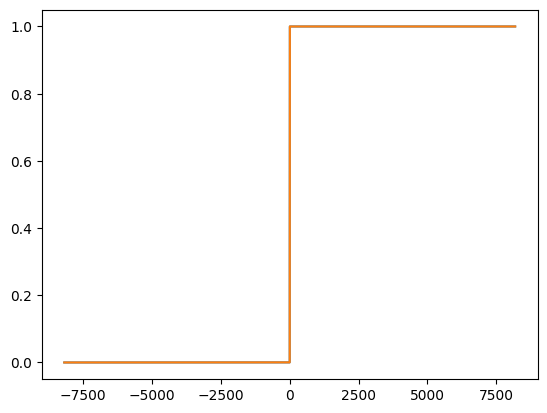

In [83]:
c = Chebyshev(-8192, 8192, 1007, sgn)

x = np.arange(-8192, 8192, 0.1)

y = np.vectorize(sgn)(x)

plt.plot(x, y)

y_real = np.vectorize(c.eval)(x)
y_real = clean(y_real)
y_real = clean(y_real)
y_real = clean(y_real)
y_real = clean(y_real)
y_real = clean(y_real)
y_real = clean(y_real)
y_real = clean(y_real)
y_real = clean(y_real)
y_real = clean(y_real)

plt.plot(x, y_real)

print(max(y - y_real))

In [80]:
c.eval(-0)

0.500000000000002

In [81]:
c.eval(3203)

1.0011945228087613

In [53]:
np.floor(4125/128)

32.0